# A. ĐỌC FILE ĐÃ QUA TIỀN XỬ LÝ

In [ ]:
# Libraries
import numpy as np
import pandas as pd
from requests import head
from sklearn import *
# Preprocessing
from src.preprocessing import *
# Visualization
from src.visualization import *
path = "data\\jewelry.csv"

In [2]:
df_users.info()

,user_id,total_orders,favorite_gems,recency,avg_order_value
0,1313554333610017315,1,[unknown],521,272.47
1,1313555541586346734,4,[diamond],56,954.70
2,1313565915903688919,4,"[topaz, fianit]",103,703.60
3,1313582215799504936,1,[pearl],135,130.00
4,1313591033442861729,6,[diamond],436,344.52


In [169]:
df_main.info()
# Bạn sẽ thấy các cột cũ như 'color', 'gem' biến mất
# Thay vào đó là hàng loạt cột mới như 'color_red', 'gem_diamond'...
display(df_main.head())

<class 'pandas.DataFrame'>
Index: 88007 entries, 0 to 95910
Data columns (total 74 columns):
 #   Column                   Non-Null Count  Dtype              
---  ------                   --------------  -----              
 0   event_time               88007 non-null  datetime64[us, UTC]
 1   order_id                 88007 non-null  str                
 2   product_id               88007 non-null  str                
 3   quantity                 88007 non-null  int64              
 4   category_id              88007 non-null  str                
 5   brand_id                 88007 non-null  str                
 6   price                    88007 non-null  float64            
 7   user_id                  88007 non-null  str                
 8   hour                     88007 non-null  int32              
 9   day                      88007 non-null  int32              
 10  month                    88007 non-null  int32              
 11  day_of_week              88007 non-null  int

,event_time,order_id,product_id,quantity,category_id,brand_id,price,user_id,hour,day,...,category_code_ring,category_code_souvenir,category_code_stud,category_code_unknown,price_segment_High,price_segment_Low,price_segment_Mid,price_scaled,quantity_scaled,hour_scaled
0,2018-12-01 11:40:29+00:00,1924719191579951782,1842195256808833386,1,1806829201890738522,0,561.51,1515915625207851155,11,1,...,0,0,0,0,1,0,0,0.136204,0.0,0.478261
1,2018-12-01 17:38:31+00:00,1924899396621697920,1806829193678291446,1,1806829201848795479,unknown,212.14,1515915625071969944,17,1,...,0,0,0,1,0,0,1,0.051308,0.0,0.739130
2,2018-12-02 13:53:42+00:00,1925511016616034733,1842214461889315556,1,1806829201915904347,1,54.66,1515915625048493557,13,2,...,0,0,0,0,0,1,0,0.013042,0.0,0.565217
3,2018-12-02 17:44:02+00:00,1925626951238681511,1835566849434059453,1,1806829201915904347,0,88.90,1515915625207630915,17,2,...,0,0,0,0,0,1,0,0.021362,0.0,0.739130
4,2018-12-02 21:30:19+00:00,1925740842841014667,1873936840742928865,1,1806829201924292956,0,417.67,1515915625175329378,21,2,...,0,0,0,0,0,0,1,0.101251,0.0,0.913043


In [ ]:
# display(df_rules.head())
# fp_model = FPGrowth(df_rules=df_rules)
# print("⏳ Đang tìm tập phổ biến (FP-Growth)...")
# fp_model.build_fp_tree_and_mine(min_support=0.0005)
# print("⏳ Đang sinh luật kết hợp...")
# rules_df = fp_model.generate_rules(metric='lift', min_threshold=1)


# num_itemsets = len(fp_model.frequent_itemsets)
# print(f"Tìm thấy: {num_itemsets} tập phổ biến.")

# # 2. Hiển thị số lượng luật kết hợp (Association Rules)
# num_rules = len(rules_df)
# print(f"Sinh ra được: {num_rules} luật kết hợp.")

# if not rules_df.empty: display(rules_df.sort_values('lift', ascending=False).head())

,order_id,item_list
0,1924719191579951782,[earring]
1,1925511016616034733,[pendant]
2,1925626951238681511,[pendant]
3,1925740842841014667,[necklace]
4,1925760595336888995,[earring]


⏳ Đang tìm tập phổ biến (FP-Growth)...
⏳ Đang sinh luật kết hợp...
✅ Tìm thấy: 24 tập phổ biến.
✅ Sinh ra được: 4 luật kết hợp.


,antecedents,consequents,antecedent support,consequent support,support,confidence,lift,representativity,leverage,conviction,zhangs_metric,jaccard,certainty,kulczynski
3,frozenset({earring}),"frozenset({ring, necklace})",0.391583,0.001460,0.000707,0.001805,1.235679,1.0,0.000135,1.000345,0.313483,0.001801,0.000345,0.242838
2,"frozenset({ring, necklace})",frozenset({earring}),0.001460,0.391583,0.000707,0.483871,1.235679,1.0,0.000135,1.178808,0.191008,0.001801,0.151686,0.242838
1,frozenset({earring}),"frozenset({ring, pendant})",0.391583,0.010239,0.004099,0.010467,1.022278,1.0,0.000089,1.000231,0.035819,0.010305,0.000230,0.205387
0,"frozenset({ring, pendant})",frozenset({earring}),0.010239,0.391583,0.004099,0.400307,1.022278,1.0,0.000089,1.014547,0.022018,0.010305,0.014339,0.205387


# B. HUẤN LUYỆN MÔ HÌNH


In [171]:
segmentation = KMeansSegmentation(df_users)
df_clustered = segmentation.train(n_clusters=4)
df_profile = segmentation.profile_clusters()
display(df_profile)

,recency,total_orders,avg_order_value,user_count,top_favorite_gems
cluster,,,,,
0,183.93,15.74,479.53,2026,"[diamond, fianit, topaz, pearl]"
1,224.40,1.22,133.37,12485,"[fianit, diamond, topaz, pearl]"
2,171.88,1.29,590.65,14114,"[diamond, fianit, topaz, pearl]"
3,692.57,1.53,360.48,3591,"[diamond, fianit, topaz, pearl]"


/home/toon/datamining2802/Data-mining/src/visualization.py:281: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(
/home/toon/datamining2802/Data-mining/src/visualization.py:281: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(


ValueError: Could not interpret value `total_spend` for `y`. An entry with this name does not appear in `data`.

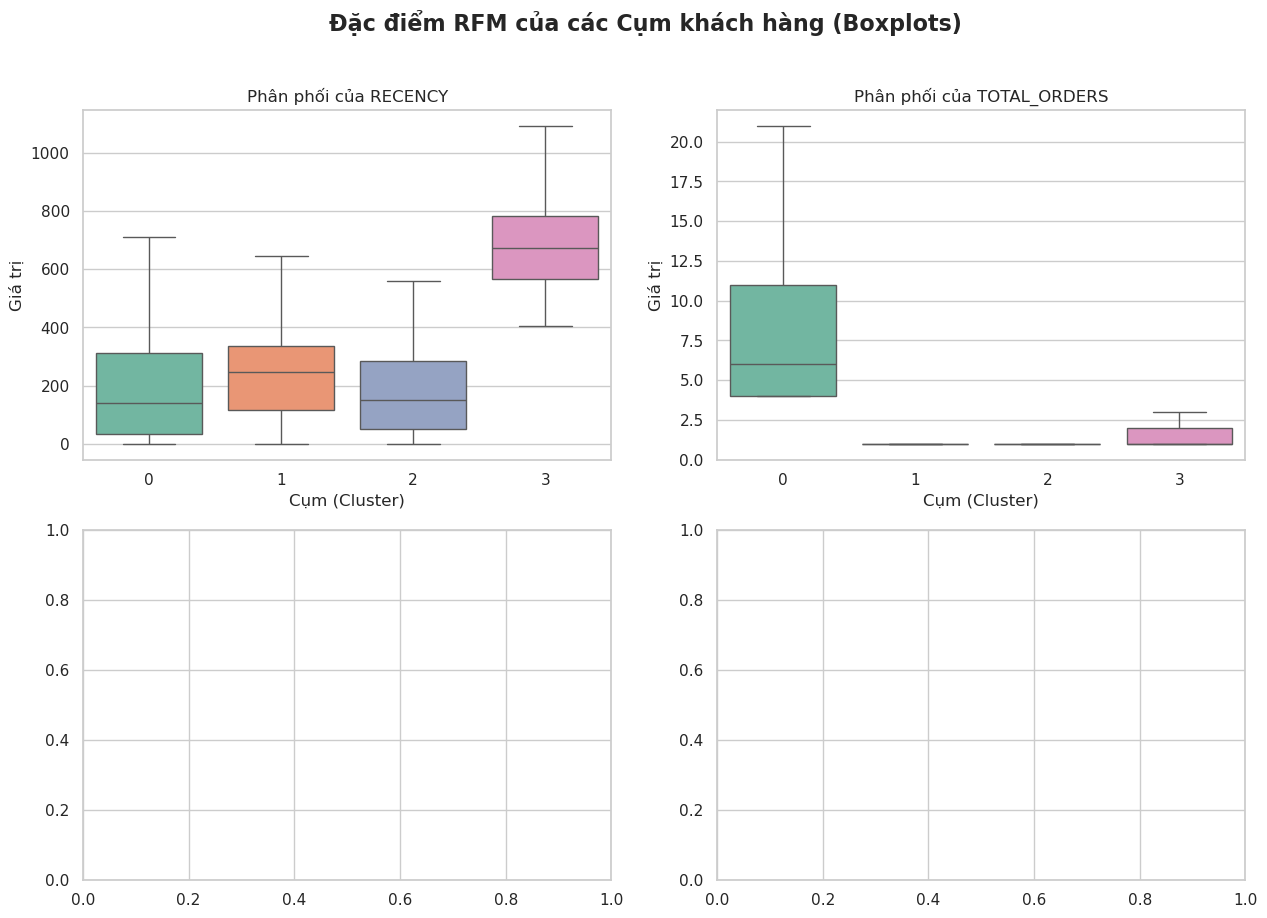

In [172]:
plot_cluster_boxplots(df_clustered)

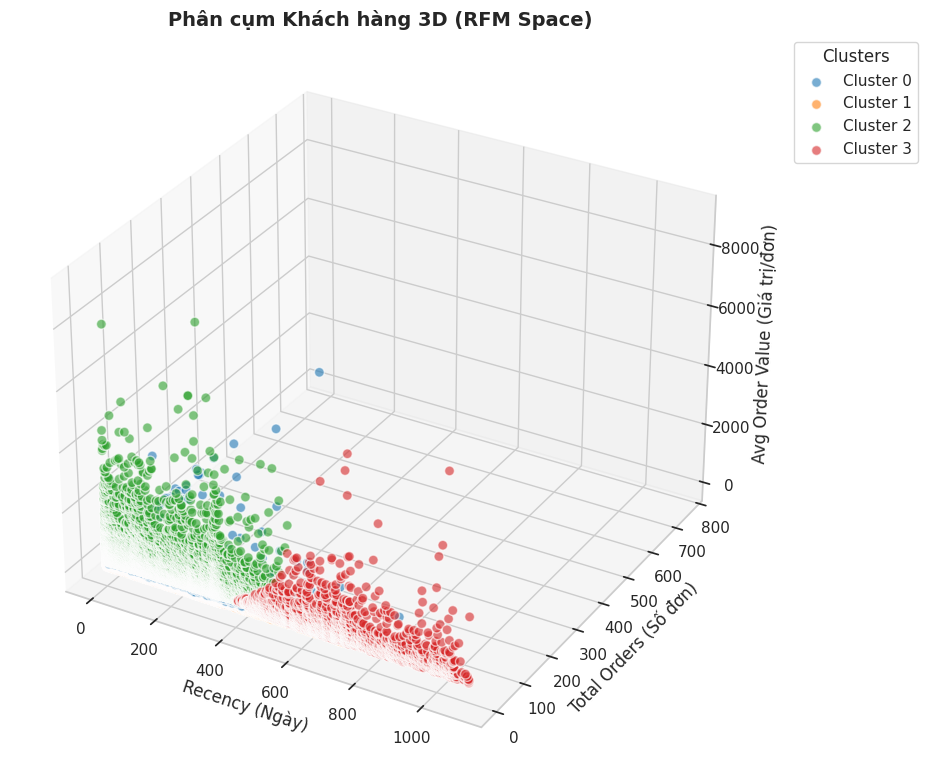

In [ ]:
plot_rfm_3d_scatter(df_clustered)

# C. VẼ BIỂU ĐỒ

c:\Users\lttin\Desktop\DataMining\src\visualization.py:173: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(


Đã lưu biểu đồ tại: image\hours_in_day_trend


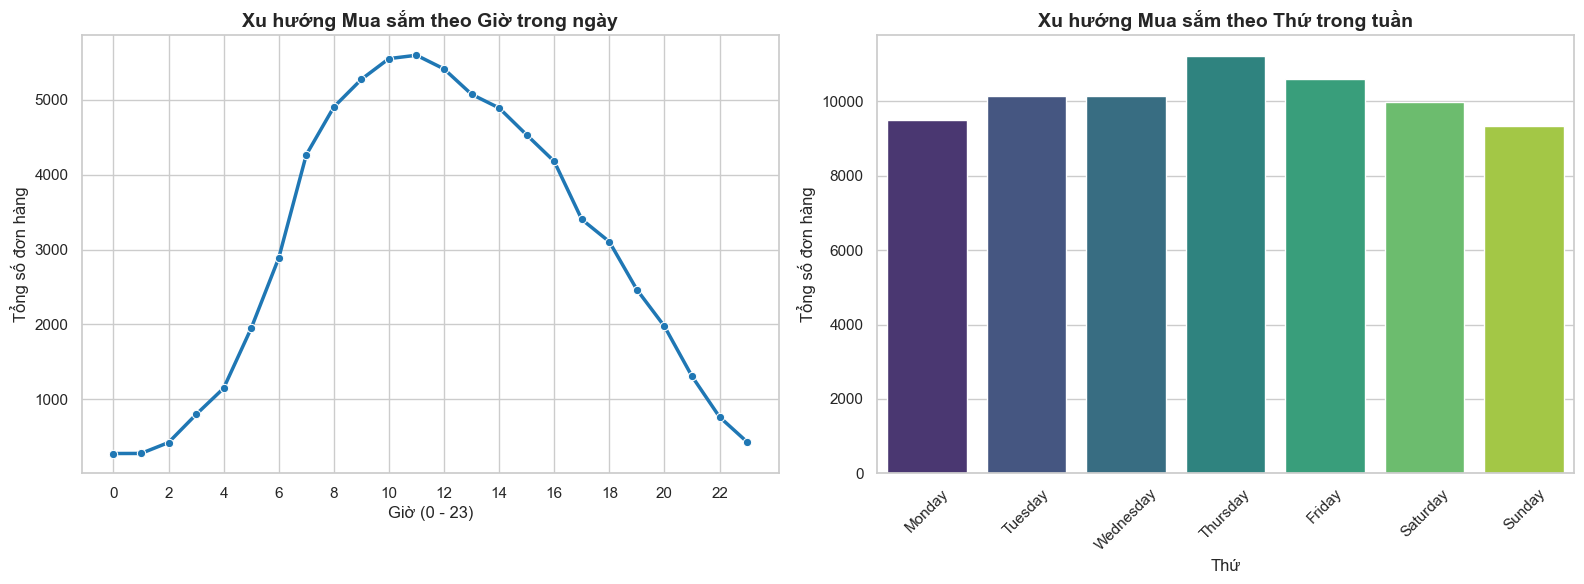

In [ ]:
plot_temporal_trends(df_main, save_path="image\\hours_in_day_trend")